# Ensemble Models

**Working Example.** Copy this file, rename it, and modify *your* copy.
See earlier notebooks for more information. 

- Author: Caleb Sellinger
- Date: 2026-08-02
- Dataset: Seaborn Penguins
- Target: species

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M5. Ensemble Models

This notebook fits a single model and 
two ensembles and 
reports their test scores side by side. 

The analyst decides whether an ensemble's extra complexity is earned, that is, 
whether it creates a real gain, 
rather than just noise.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

An **ensemble** combines many models 
so their errors partly cancel. 

This module reuses the Module 3 classification setup and asks one question: 

- Does combining models beat the single model in this problem?

## Overview

This project uses the penguins dataset.
We choose to predict the target `species`.
This target is a **discrete category**, so we have a:

- supervised ML problem (because we've chosen a target)
- an ensemble model because we are choosing to combine approaches to see if we can improve on the classification model in Module 3.

Customize the overview in your copy to reflect your dataset and choices.

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. Ensemble Models and When To Use

A single decision tree can be unstable:
small data changes swing it. 

**Ensembles** fit many models and combine them:

- **Random forest** - many trees on random subsets of rows and features; they vote.
- **Gradient boosting** - trees added in sequence, each correcting the last one's errors.

Ensembles often improve accuracy and stability - but not always.

They cost more to train and are harder to explain. 

The right question is:

Did it earn its complexity *on held-out data* for this problem?

It is a judgment that the analyst makes and defends by comparing test scores.

## Section 1. Project Setup and Imports

In [266]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import r_regression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05", level="DEBUG")
log_header(LOG, "M05")


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-08-02 20:48:14 | INFO | M05 | === RUN START ===
2026-08-02 20:48:14 | INFO | M05 | project=M05
2026-08-02 20:48:14 | INFO | M05 | repo_dir=CS44670-Module-5
2026-08-02 20:48:14 | INFO | M05 | python=3.14.6
2026-08-02 20:48:14 | INFO | M05 | os=Windows 11
2026-08-02 20:48:14 | INFO | M05 | shell=powershell
2026-08-02 20:48:14 | INFO | M05 | cwd=notebooks
2026-08-02 20:48:14 | INFO | M05 | github_actions=False
2026-08-02 20:48:14 | INFO | M05 | Confirming installation:
2026-08-02 20:48:14 | INFO | M05 |   python:       3.14.6
2026-08-02 20:48:14 | INFO | M05 |   pandas:       3.0.5
2026-08-02 20:48:14 | INFO | M05 |   numpy:        2.5.1
2026-08-02 20:48:14 | INFO | M05 |   scikit-learn: 1.9.0
2026-08-02 20:48:14 | INFO | M05 |   seaborn:      0.13.2
2026-08-02 20:48:14 | INFO | M05 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [267]:
# === Section 2. Load and Prepare the Data ===


# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "chip_companies_financials.csv"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "sergionefedov/global-semiconductor-industry-2010-2026",
    DATASET_NAME,
)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

# CUSTOM: ANALYST CHOICE - the categorical target to classify.
TARGET_COL: Final[str] = "segment"

# CUSTOM: Numeric features used to predict the target.
FEATURE_COLS: Final[list[str]] = [
    "revenue_usd_bn",
    "operating_margin_pct",
    "operating_income_usd_bn",
    "capex_usd_bn",
]

required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

top_segments = df_model[TARGET_COL].value_counts().head(4).index
df_model = df_model[df_model[TARGET_COL].isin(top_segments)].copy()
LOG.info(f"Filtered rows: {df_model.shape[0]}")
LOG.info(f"Class counts after filtering:\n{df_model[TARGET_COL].value_counts()}")

2026-08-02 20:48:14 | INFO | M05 | Loading dataset: chip_companies_financials.csv
2026-08-02 20:48:14 | INFO | M05 | Loaded: 617 rows (instances), 10 columns
2026-08-02 20:48:14 | INFO | M05 | Original rows: 617
2026-08-02 20:48:14 | INFO | M05 | Model rows:    617
2026-08-02 20:48:14 | INFO | M05 | Classes in target 'segment': ['eda_software', 'equipment_cleaning', 'equipment_diversified', 'equipment_etch', 'equipment_inspection', 'equipment_litho', 'fabless_ai', 'fabless_cpu_gpu', 'fabless_diversified', 'fabless_gpu', 'fabless_mobile', 'fabless_networking', 'foundry', 'idm_analog', 'idm_automotive', 'idm_cpu', 'idm_diversified', 'idm_memory', 'idm_micro', 'idm_power']
2026-08-02 20:48:14 | DEBUG | M05 | Class counts:
segment
foundry                  102
idm_memory                70
idm_automotive            51
fabless_ai                37
fabless_mobile            34
fabless_diversified       34
idm_analog                34
equipment_diversified     34
eda_software              34
fa

## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.

In [268]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train: pd.DataFrame
X_test: pd.DataFrame

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-08-02 20:48:14 | INFO | M05 | Train instances: 208
2026-08-02 20:48:14 | INFO | M05 | Test instances: 52


## Section 4. Fit a Single Model and Two Ensembles

ANALYST CHOICE

The baseline is a single decision tree. 

The ensembles are a random forest and a gradient-boosting model. 

The analyst must tune their settings (n_estimators, max_depth, ...).

We fit sensible defaults so you can compare them fairly.

In [269]:
# === Section 4. Fit a Single Model and Two Ensembles ===

"""Fit one single model and two ensembles
on the same training data.

WHY: A fair comparison needs the
 same training data and the same split.
 We fit a single tree as the baseline,
 then two ensembles to compare against it.
"""
LOG.info("Fitting single tree + two ensembles")

modelA = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)
LOG.debug("  fitted: single_tree")

modelB = RandomForestClassifier(n_estimators=10, random_state=RANDOM_STATE)
modelB.fit(X_train, y_train)
LOG.debug("  fitted: random_forest")

modelC = GradientBoostingClassifier(n_estimators=10, random_state=RANDOM_STATE)
modelC.fit(X_train, y_train)
LOG.debug("  fitted: gradient_boosting")

2026-08-02 20:48:14 | INFO | M05 | Fitting single tree + two ensembles
2026-08-02 20:48:14 | DEBUG | M05 |   fitted: single_tree
2026-08-02 20:48:14 | DEBUG | M05 |   fitted: random_forest
2026-08-02 20:48:14 | DEBUG | M05 |   fitted: gradient_boosting


## Section 5. Compare on Held-Out Data

2026-08-02 20:48:14 | INFO | M05 |   single_tree        test accuracy = 0.904
2026-08-02 20:48:14 | INFO | M05 |   random_forest      test accuracy = 0.904
2026-08-02 20:48:14 | INFO | M05 |   gradient_boosting  test accuracy = 0.885


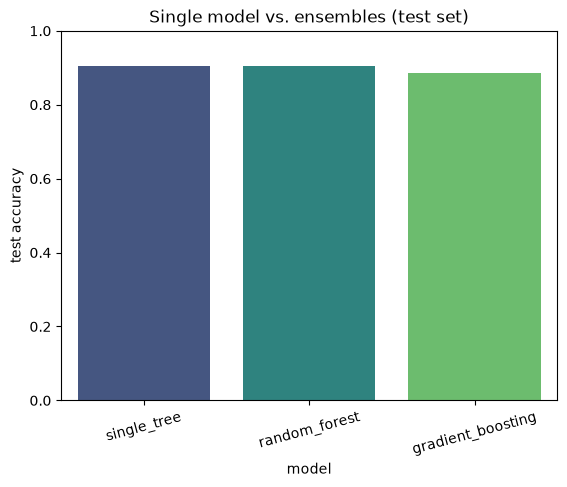

2026-08-02 20:48:14 | INFO | M05 | Best model: single_tree with test accuracy = 0.904


In [270]:
# === Section 5. Compare on Held-Out Data ===

"""Score every model on the same test set and chart the results.

WHY: The only fair comparison is on data none of them trained on.

Code only reports numbers.

Whether an ensemble's gain
is large enough to justify its cost
depends on this specific problem,
and requires analyst judgment.
"""

# score each model on the held-out test set
# accuracy_score returns a numpy scalar - wrap in float() for compatibility
A_test: np.ndarray = modelA.predict(X_test)
B_test: np.ndarray = modelB.predict(X_test)
C_test: np.ndarray = modelC.predict(X_test)


acc_single_tree: float = float(accuracy_score(y_test, A_test))
acc_random_forest: float = float(accuracy_score(y_test, B_test))
acc_gradient_boosting: float = float(accuracy_score(y_test, C_test))

LOG.info(f"  {'single_tree':18s} test accuracy = {acc_single_tree:.3f}")
LOG.info(f"  {'random_forest':18s} test accuracy = {acc_random_forest:.3f}")
LOG.info(f"  {'gradient_boosting':18s} test accuracy = {acc_gradient_boosting:.3f}")

# build a dict for charting
# The keys are the model names,
# and the values are the test accuracies.
scores: dict[str, float] = {
    "single_tree": acc_single_tree,
    "random_forest": acc_random_forest,
    "gradient_boosting": acc_gradient_boosting,
}

# start a new figure
plt.figure()

# create a bar chart of the scores
x_keys = list(scores.keys())
y_values = list(scores.values())

# create a bar chart with seaborn (uses matplotlib under the hood)
sns.barplot(x=x_keys, y=y_values, palette="viridis", hue=x_keys, legend=False)

# set y-axis limits to [0, 1] since accuracy is a percentage
plt.ylim(0, 1)

# label the axes and title
plt.xlabel("model")
plt.ylabel("test accuracy")
plt.title("Single model vs. ensembles (test set)")

# slight rotation for readability (optional)
plt.xticks(rotation=15)

# show the plot
plt.show()

# find the best model by name (the one with the highest test accuracy)
best: str = max(scores, key=scores.get)  # type: ignore[arg-type]
LOG.info(f"Best model: {best} with test accuracy = {scores[best]:.3f}")

### Evaluating the Models

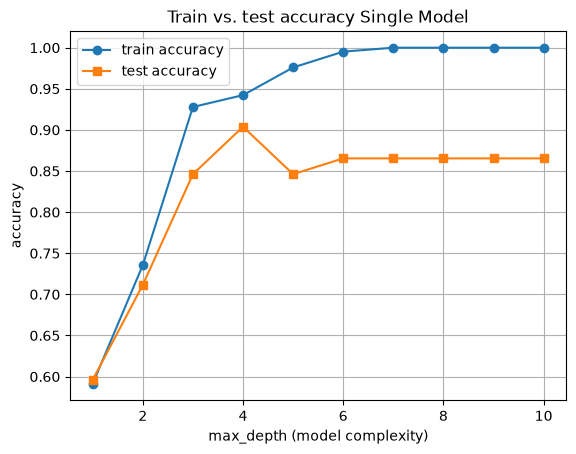

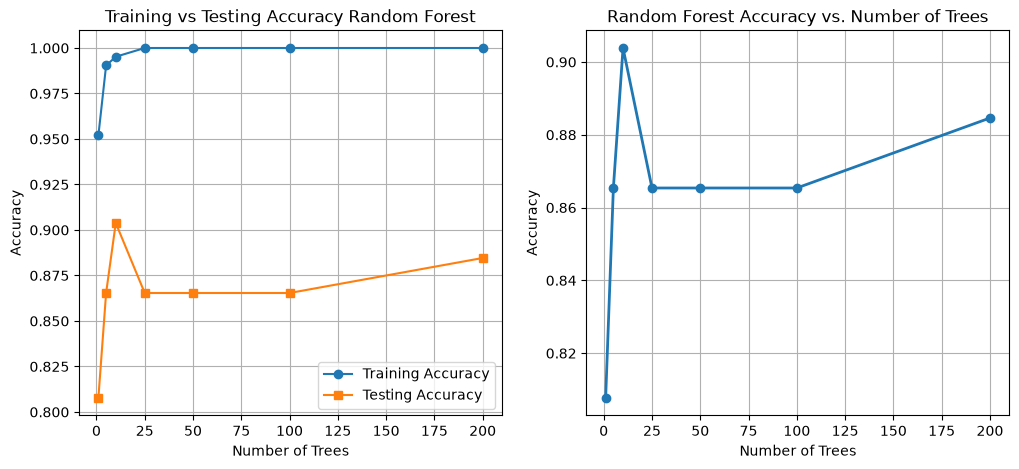

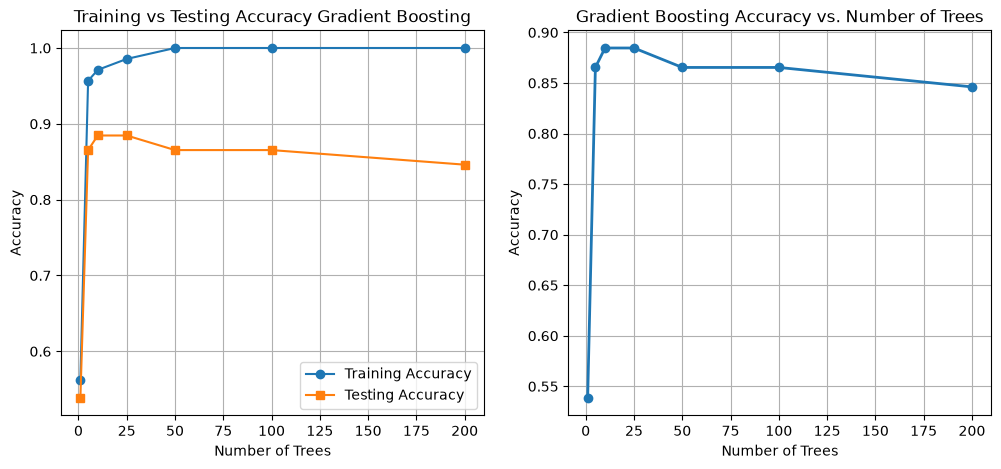

In [271]:
# === Section 6. How Parameter Selection Affects Performance ===

A_train: np.ndarray = modelA.predict(X_train)
B_train: np.ndarray = modelB.predict(X_train)
C_train: np.ndarray = modelC.predict(X_train)

# CUSTOM: ANALYST CHOICE
# for penquins, sweep from 1 to 12 as a good range.
# THIS IS DATA SET DEPENDENT and ANALYST CHOICE.

MAX_SWEEP: Final[int] = 10

# Declare lists to hold the depths and corresponding train/test scores.
depths: list[int] = list(range(1, MAX_SWEEP + 1))
train_scores: list[float] = []
test_scores: list[float] = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    acc_score_train = accuracy_score(y_train, model.predict(X_train))
    acc_score_test = accuracy_score(y_test, model.predict(X_test))

    # Use float() to convert from numpy Float to native Python float for better compatibility with other code and libraries.
    train_scores.append(float(acc_score_train))
    test_scores.append(float(acc_score_test))

# start a new figure
plt.figure()

# plot the train and test scores against the depths
plt.plot(depths, train_scores, marker="o", label="train accuracy")
plt.plot(depths, test_scores, marker="s", label="test accuracy")

# label the axes and add a title and legend
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.title("Train vs. test accuracy Single Model")
plt.legend()
plt.grid(True)

# show the plot
plt.show()

# Test accuracy vs number of trees for Random Forest
tree_counts = [1, 5, 10, 25, 50, 100, 200]
accuraciesRF = []

for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuraciesRF.append(accuracy_score(y_test, y_pred))

# Test vs Train Accuracy for Random Forest
train_acc = []
test_acc = []

for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(tree_counts, train_acc, marker='o', label='Training Accuracy')
axes[0].plot(tree_counts, test_acc, marker='s', label='Testing Accuracy')
axes[0].set_xlabel("Number of Trees")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training vs Testing Accuracy Random Forest")
axes[0].legend()
axes[0].grid(True)
axes[1].plot(tree_counts, accuraciesRF, marker='o', linewidth=2)
axes[1].set_xlabel("Number of Trees")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Random Forest Accuracy vs. Number of Trees")
axes[1].grid(True)

plt.show()

# Test accuracy vs number of trees for Gradient Boosting
tree_counts = [1, 5, 10, 25, 50, 100, 200]
accuraciesGB = []

for n in tree_counts:
    model = GradientBoostingClassifier(n_estimators=n, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuraciesGB.append(accuracy_score(y_test, y_pred))

# Test vs Train Accuracy for Gradient Boosting
train_acc_gb = []
test_acc_gb = []

for n in tree_counts:
    model = GradientBoostingClassifier(n_estimators=n, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    train_acc_gb.append(model.score(X_train, y_train))
    test_acc_gb.append(model.score(X_test, y_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(tree_counts, train_acc_gb, marker='o', label='Training Accuracy')
axes[0].plot(tree_counts, test_acc_gb, marker='s', label='Testing Accuracy')
axes[0].set_xlabel("Number of Trees")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training vs Testing Accuracy Gradient Boosting")
axes[0].legend()
axes[0].grid(True)
axes[1].plot(tree_counts, accuraciesGB, marker='o', linewidth=2)
axes[1].set_xlabel("Number of Trees")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Gradient Boosting Accuracy vs. Number of Trees")
axes[1].grid(True)

plt.show()

### Confusion Matrix

2026-08-02 20:48:16 | INFO | M05 | ==========Random Forest==========
2026-08-02 20:48:16 | INFO | M05 | Random Forest Test Accuracy: 0.904
2026-08-02 20:48:16 | INFO | M05 | Per-class precision / recall / F1:
2026-08-02 20:48:16 | DEBUG | M05 | 
                precision    recall  f1-score   support

    fabless_ai       0.88      1.00      0.93         7
       foundry       0.91      0.95      0.93        21
idm_automotive       0.91      1.00      0.95        10
    idm_memory       0.91      0.71      0.80        14

      accuracy                           0.90        52
     macro avg       0.90      0.92      0.90        52
  weighted avg       0.90      0.90      0.90        52

2026-08-02 20:48:16 | INFO | M05 | Showing confusion matrix (rows = actual, cols = predicted)


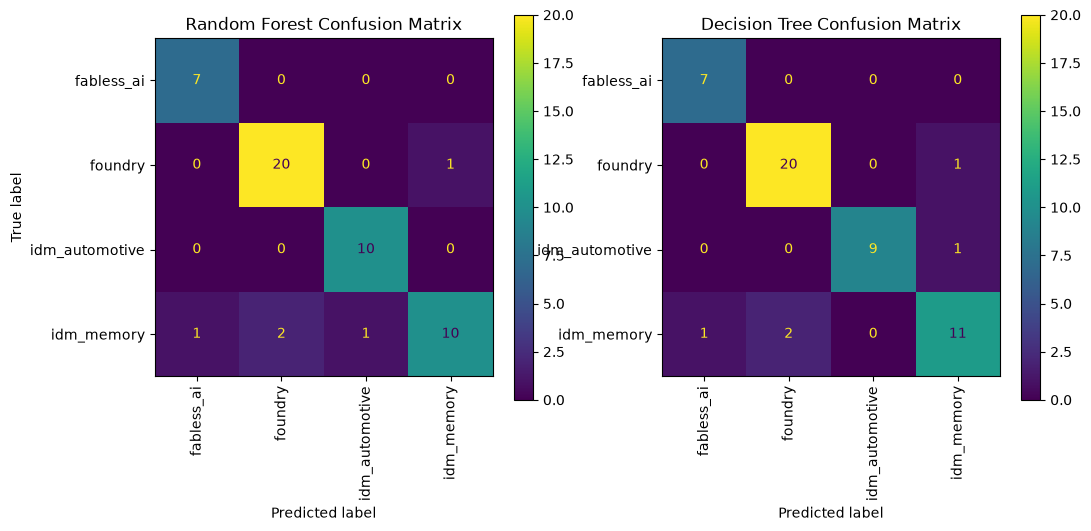

2026-08-02 20:48:17 | INFO | M05 | ==========Decision Tree==========
2026-08-02 20:48:17 | INFO | M05 | Decision Tree Test Accuracy: 0.904
2026-08-02 20:48:17 | INFO | M05 | Per-class precision / recall / F1:
2026-08-02 20:48:17 | DEBUG | M05 | 
                precision    recall  f1-score   support

    fabless_ai       0.88      1.00      0.93         7
       foundry       0.91      0.95      0.93        21
idm_automotive       1.00      0.90      0.95        10
    idm_memory       0.85      0.79      0.81        14

      accuracy                           0.90        52
     macro avg       0.91      0.91      0.91        52
  weighted avg       0.91      0.90      0.90        52



In [272]:
y_pred = modelB.predict(X_test)
y_pred2 = modelA.predict(X_test)

test_acc: float = float(accuracy_score(y_test, y_pred))
LOG.info("==========Random Forest==========")
LOG.info(f"Random Forest Test Accuracy: {test_acc:.3f}")

LOG.info("Per-class precision / recall / F1:")
LOG.debug(f"\n{classification_report(y_test, y_pred)}")

LOG.info("Showing confusion matrix (rows = actual, cols = predicted)")

# start a figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# create the confusion matrix display
ConfusionMatrixDisplay.from_estimator(modelB, X_test, y_test, ax=axes[0])
ConfusionMatrixDisplay.from_estimator(modelA, X_test, y_test, ax=axes[1])

# set the title
axes[0].set_title("Random Forest Confusion Matrix")
axes[1].set_title("Decision Tree Confusion Matrix")

# set x labels vertical
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation="vertical")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation="vertical")

# show the plot
plt.show()

test_acc2: float = float(accuracy_score(y_test, y_pred2))
LOG.info("==========Decision Tree==========")
LOG.info(f"Decision Tree Test Accuracy: {test_acc2:.3f}")

LOG.info("Per-class precision / recall / F1:")
LOG.debug(f"\n{classification_report(y_test, y_pred2, zero_division=0)}")

### Principal Component Analysis and Correlation Matrix

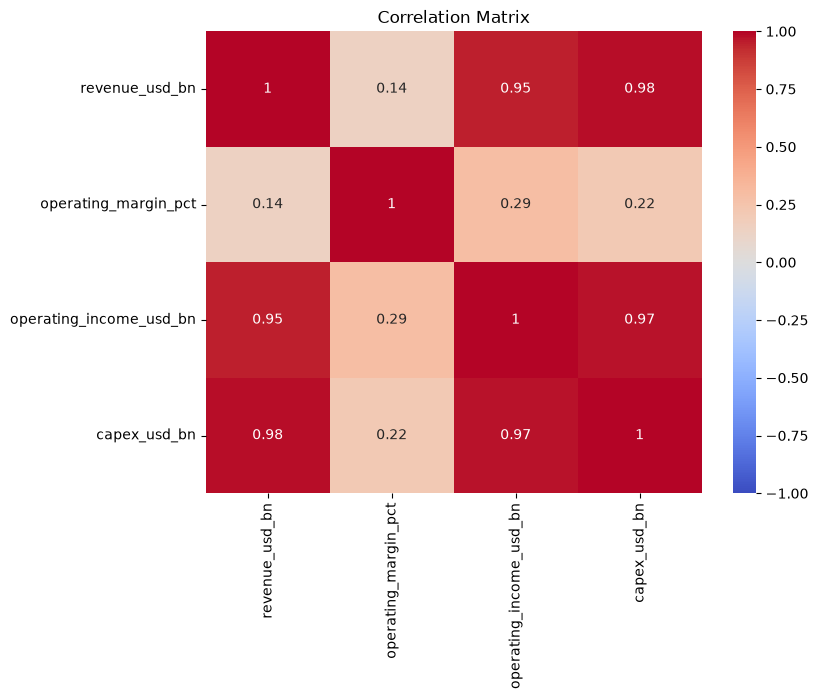

revenue_usd_bn: 0.3880
operating_margin_pct: -0.0029
operating_income_usd_bn: 0.2326
capex_usd_bn: 0.2892


In [273]:
# Correlation matrix heatmap Pandas
corr_matrix: pd.DataFrame = pd.DataFrame(X_train, columns=FEATURE_COLS).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# Calculate Pearson's R correlation coefficients against the target from sklearn's r_regression function
X = df_model[FEATURE_COLS]
y = (
    df_model[TARGET_COL].astype('category').cat.codes
)  # Convert categorical target to numeric codes

# Calculate Pearson's R correlation coefficients against the target
tar_correlations = r_regression(X, y)

# Map back to feature names for readability
for name, score in zip(FEATURE_COLS, tar_correlations, strict=True):
    print(f"{name}: {score:.4f}")

### Interpretation

Did the ensemble beat the single tree by enough to justify its cost?

The analyst must decide and defend their choice.

## Section 6. Which Features Did the Forest Rely On?

2026-08-02 20:48:17 | INFO | M05 | Random forest feature importances (high to low):
2026-08-02 20:48:17 | INFO | M05 |   operating_margin_pct 0.365
2026-08-02 20:48:17 | INFO | M05 |   capex_usd_bn         0.306
2026-08-02 20:48:17 | INFO | M05 |   operating_income_usd_bn 0.214
2026-08-02 20:48:17 | INFO | M05 |   revenue_usd_bn       0.114


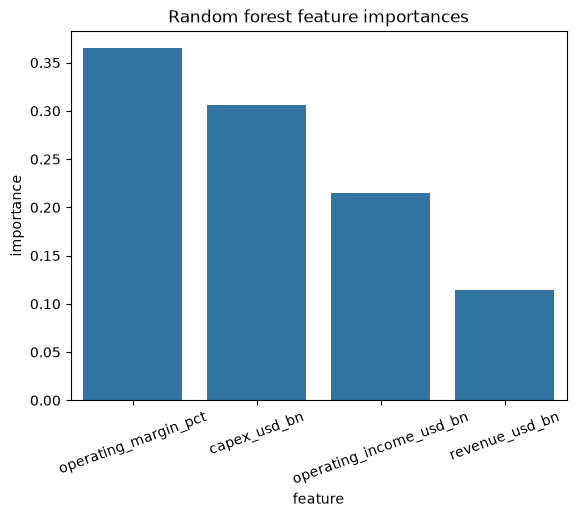

In [274]:
# === Section 6. Feature Importances (Random Forest) ===


"""Chart the random forest's feature importances.

WHY: Ensembles are harder to read than a single tree,
but a forest can still report which features it leaned on.
Importances are a clue,
not proof of causation.

Interpret them with the same care as any other finding.
"""
# get the feature importances
# from the fitted random forest model
importances: np.ndarray = modelB.feature_importances_

# argsort returns indices that would sort the array ascending
# [::-1] reverses it so the most important feature comes first
order: np.ndarray = np.argsort(importances)[::-1]
LOG.info("Random forest feature importances (high to low):")
for i in order:
    LOG.info(f"  {FEATURE_COLS[i]:20s} {importances[i]:.3f}")

# start a new figure
plt.figure()

# create x and y values for the bar chart, ordered from high to low importance
x_values = [FEATURE_COLS[i] for i in order]
y_values = importances[order]

# create a bar chart of the importances, ordered from high to low
sns.barplot(x=x_values, y=y_values)

# label the axes and title
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Random forest feature importances")

# slight rotation for readability (optional)
plt.xticks(rotation=20)

# show the plot
plt.show()

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [275]:
# === Python Summary ===

"""Record what was compared and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}   Target: {TARGET_COL} (classification)")
LOG.info("Compared: single tree vs. random forest vs. gradient boosting")
LOG.info("========================")

2026-08-02 20:48:17 | INFO | M05 | ========================
2026-08-02 20:48:17 | INFO | M05 | SUMMARY
2026-08-02 20:48:17 | INFO | M05 | ========================
2026-08-02 20:48:17 | INFO | M05 | Dataset: chip_companies_financials.csv   Target: segment (classification)
2026-08-02 20:48:17 | INFO | M05 | Compared: single tree vs. random forest vs. gradient boosting
2026-08-02 20:48:17 | INFO | M05 | ========================



### Custom Narrative

Summarize your work in this Markdown cell in your notebook.

YOUR JUDGMENT (include a summary in docs/index.md also):

- Did either ensemble beat the single tree on the test set? RandomForest beat the single tree.
- Was the gain worth the extra training cost and lost simplicity? Only a gain of 1.4 percent accuracy, so no.
- Do the feature importances match what you expected? Any surprises? 

### Next Steps

Summarize your next steps in this Markdown cell in your notebook.


## Task: Make the Notebook Yours (Apply / Extend / Explore)

This is an example.
Copy this notebook and make it your own. 

In your copy:

1. At the beginning, update the Author, the purpose, the target, etc. 
2. Remove any instructions you do not need. 

Try things like the following.

1. **Apply** - Re-run on a harder target (`"sex"`) and see whether the ensemble's
   advantage over the single tree grows when the problem is harder.
2. **Extend** - Tune `n_estimators` and `max_depth` for the random forest and report
   whether more trees kept helping or flattened out (diminishing returns).
3. **Explore** - Find a case where the ensemble does **not** beat the single tree,
   and argue in `docs/index.md` why the simpler model is the better choice there.

## Task: Final Check

- `README.md` - reflects your description, instructions, commands, and links to your executed notebook.
- `docs/index.md` - reflects your project-specific updates.
- Your GitHub **About** section has a link to your hosted documentation site.
- The executed example notebook AND your custom notebook are available in `notebooks/`.
- Keep this **working example** alongside your custom work until your work has been assessed.
- Ensure your **custom notebook** introduces and narrates **your** custom project.

## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://denisecase.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
